<a href="https://colab.research.google.com/github/jcorrigan13/NLP_DeepLearningAssingmentforITNPAI/blob/main/ITNPAI1_Assingment_DeepLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# Install libraries

!pip install transformers datasets evaluate scikit-learn matplotlib pandas
!pip install kaggle
!pip install kagglehub


In [2]:
# Import packages

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay

import torch
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments
)

In [32]:
# Kaggle setup
from google.colab import files
import os
import shutil

uploaded = files.upload()   # upload kaggle.json

os.makedirs('/root/.kaggle', exist_ok=True)
shutil.move('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

# Download dataset
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [29]:
# Download TripAdvisor data now
!kaggle datasets download -d andrewmvd/trip-advisor-hotel-reviews

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/trip-advisor-hotel-reviews
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
trip-advisor-hotel-reviews.zip: Skipping, found more recently modified local copy (use --force to force download)


In [33]:
#Downloading IMDB dataset

from datasets import load_dataset

imdb = load_dataset("imdb")
imdb_train = pd.DataFrame(imdb["train"])
imdb_test = pd.DataFrame(imdb["test"])

Step 2:

Exploratory Data Analysis of the two datasets.

This is so we can understand what we are working with.

In [34]:
#Intial investigation of Trip Advisor dataset:

# Checking collumns, labels

# Unzip the TripAdvisor dataset
!unzip -o /content/trip-advisor-hotel-reviews.zip

# Load the data into a pandas DataFrame
trip_df = pd.read_csv('tripadvisor_hotel_reviews.csv')


print(trip_df.columns)
print(trip_df.shape)
print(trip_df["Rating"].value_counts().sort_index())
trip_df.head()

Archive:  /content/trip-advisor-hotel-reviews.zip
  inflating: tripadvisor_hotel_reviews.csv  
Index(['Review', 'Rating'], dtype='object')
(20491, 2)
Rating
1    1421
2    1793
3    2184
4    6039
5    9054
Name: count, dtype: int64


,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Index(['text', 'label', 'review_length'], dtype='object')
(25000, 3)
                                                text  label  review_length
0  I rented I AM CURIOUS-YELLOW from my video sto...      0            288
1  "I Am Curious: Yellow" is a risible and preten...      0            214
2  If only to avoid making this type of film in t...      0             93
3  This film was probably inspired by Godard's Ma...      0            118
4  Oh, brother...after hearing about this ridicul...      0            311


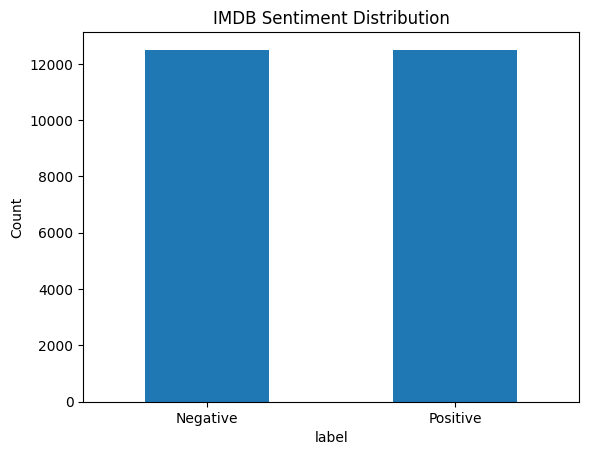

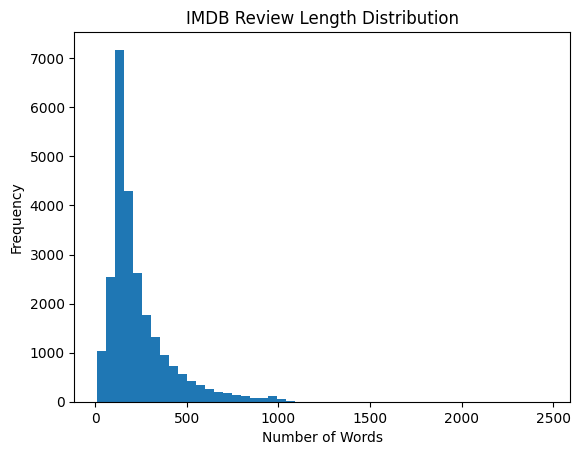

,review_length
count,25000.000000
mean,233.787200
std,173.733032
min,10.000000
25%,127.000000
50%,174.000000
75%,284.000000
max,2470.000000


In [38]:
# Intial investigation of the IMDB dataset
print(imdb_train.columns)
print(imdb_train.shape)
print(imdb_train.head())

# Visualisation distribution
imdb_train["label"].value_counts().plot(kind="bar")
plt.title("IMDB Sentiment Distribution")
plt.xticks([0,1], ["Negative","Positive"], rotation=0)
plt.ylabel("Count")
plt.show()

# Review length
imdb_train["review_length"] = imdb_train["text"].apply(lambda x: len(x.split()))

plt.hist(imdb_train["review_length"], bins=50)
plt.title("IMDB Review Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()
imdb_train["review_length"].describe()